In [1]:
from sklearn.datasets import fetch_20newsgroups
import numpy as np

# 3개 주제 지정
categories = ['comp.graphics', 'sci.space', 'talk.religion.misc']

# 전체 train 데이터 불러오기
data = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

print(f"전체 샘플: {len(data.data)}")
print(f"주제: {data.target_names}")
print(f"각 주제별 샘플 수: {np.bincount(data.target)}")

전체 샘플: 1554
주제: ['comp.graphics', 'sci.space', 'talk.religion.misc']
각 주제별 샘플 수: [584 593 377]


In [2]:
# 각 주제 인덱스 찾기
comp_idx = data.target == 0  # comp.graphics
sci_idx = data.target == 1   # sci.space
talk_idx = data.target == 2  # talk.religion.misc

# 각 주제에서 20개씩 랜덤 샘플링
samples_per_category = 20
comp_samples = np.random.choice(np.where(comp_idx)[0], samples_per_category, replace=False)
sci_samples = np.random.choice(np.where(sci_idx)[0], samples_per_category, replace=False)
talk_samples = np.random.choice(np.where(talk_idx)[0], samples_per_category, replace=False)

# 결과 확인
print(f"comp.graphics 샘플: {len(comp_samples)}개")
print(f"sci.space 샘플: {len(sci_samples)}개")
print(f"talk.religion.misc 샘플: {len(talk_samples)}개")

# 샘플 데이터 보기 (첫 번째씩)
print("\n=== 샘플 데이터 ===")
print("comp.graphics:", data.data[comp_samples[0]][:200], "...")
print("sci.space:", data.data[sci_samples[0]][:200], "...")
print("talk.religion.misc:", data.data[talk_samples[0]][:200], "...")

comp.graphics 샘플: 20개
sci.space 샘플: 20개
talk.religion.misc 샘플: 20개

=== 샘플 데이터 ===
comp.graphics: 
  For a commerical package try WAVE from  Precision Visuals
                                           505-530-6563

  For a free package try KHOROS from University of New Mexico
                     ...
sci.space: 

The Japanese are still on the learning curve as far as nuclear power goes.
This means that unlike the Germans (who do great things all by themselves)
the Japanese tie up with foreign companies. The  ...
talk.religion.misc: 
	COuld he?  And the first three that died, when guns ablazing in came
	the BATF and FBI?

	I imagine I would have some trouble giving up my children to
	someone who had just shot -- what -- two of th ...


In [3]:
all_samples = np.concatenate([comp_samples, sci_samples, talk_samples])
X_sampled = [data.data[i] for i in all_samples]
y_sampled = data.target[all_samples]

print(f"최종 데이터셋: {len(X_sampled)}개 샘플")
print(f"라벨 분포: {np.bincount(y_sampled)}")

최종 데이터셋: 60개 샘플
라벨 분포: [20 20 20]


In [4]:
from sklearn.datasets import fetch_20newsgroups
import numpy as np

# 3개 주제 지정 (이미 remove 옵션 포함)
categories = ['comp.graphics', 'sci.space', 'talk.religion.misc']

# headers, footers, quotes 제거하면서 데이터 불러오기
data = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),  # ✅ 본문만 남김
    random_state=42
)

print(f"전체 샘플: {len(data.data)}")
print(f"주제: {data.target_names}")
print(f"각 주제별 샘플 수: {np.bincount(data.target)}")
print("-" * 50)

# 각 주제에서 20개씩 추출 (이미 제거된 깨끗한 데이터)
comp_idx = data.target == 0  # comp.graphics
sci_idx = data.target == 1   # sci.space
talk_idx = data.target == 2  # talk.religion.misc

samples_per_category = 20
comp_samples = np.random.choice(np.where(comp_idx)[0], samples_per_category, replace=False)
sci_samples = np.random.choice(np.where(sci_idx)[0], samples_per_category, replace=False)
talk_samples = np.random.choice(np.where(talk_idx)[0], samples_per_category, replace=False)

# 최종 데이터셋 (본문만 사용, 총 60개)
all_samples = np.concatenate([comp_samples, sci_samples, talk_samples])
X_sampled = [data.data[i] for i in all_samples]  # ✅ headers/footers/quotes 제거된 텍스트
y_sampled = data.target[all_samples]

print(f"✅ 최종 데이터셋: {len(X_sampled)}개 샘플 (본문만)")
print(f"✅ 라벨 분포: {np.bincount(y_sampled)}")
print(f"✅ 첫 번째 comp.graphics 샘플 (본문만):")
print(X_sampled[0][:300] + "...")

전체 샘플: 1554
주제: ['comp.graphics', 'sci.space', 'talk.religion.misc']
각 주제별 샘플 수: [584 593 377]
--------------------------------------------------
✅ 최종 데이터셋: 60개 샘플 (본문만)
✅ 라벨 분포: [20 20 20]
✅ 첫 번째 comp.graphics 샘플 (본문만):
I am looking for some information of hidden line removal using Roberts
algorithm.  Something with code, or pseudo code would be especially
helpful.

I am required to do this for a class, due Monday (we have very little
time to implement these changes, it is a VERY FAST paced class).  The
notes given...


In [5]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# 1) 3개 주제 데이터 불러오기 (이미 headers/footers/quotes 제거)
categories = ['comp.graphics', 'sci.space', 'talk.religion.misc']
data = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

# 2) 각 주제별 20개 샘플 추출
comp_idx = data.target == 0
sci_idx = data.target == 1
talk_idx = data.target == 2

samples_per_category = 20
comp_samples = np.random.choice(np.where(comp_idx)[0], samples_per_category, replace=False)
sci_samples = np.random.choice(np.where(sci_idx)[0], samples_per_category, replace=False)
talk_samples = np.random.choice(np.where(talk_idx)[0], samples_per_category, replace=False)

all_samples = np.concatenate([comp_samples, sci_samples, talk_samples])
X_sampled = [data.data[i] for i in all_samples]  # 텍스트 리스트 (60개)
y_sampled = data.target[all_samples]            # 라벨 (60개)

print(f"✅ 샘플링 완료: {len(X_sampled)}개 텍스트")

# 3) CountVectorizer로 빈도 벡터 변환
vectorizer = CountVectorizer(
    max_features=1000,      # 최대 1000개 단어만 사용
    min_df=2,               # 2개 이상 문서에 등장한 단어만
    stop_words='english'    # 영어 불용어 제거
)

# fit_transform: 어휘사전 학습 + 벡터 변환 (한 번에)
X_vectorized = vectorizer.fit_transform(X_sampled)

print(f"✅ 벡터화 완료:")
print(f"   - 벡터 형태: {X_vectorized.shape}")  # (60 문서, 1000 단어)
print(f"   - 어휘사전 크기: {len(vectorizer.get_feature_names_out())}")
print(f"   - 희소 행렬 비율: {X_vectorized.nnz / (X_vectorized.shape[0] * X_vectorized.shape[1]) * 100:.1f}%")

# 4) 결과 확인
print("\n=== 첫 번째 샘플 벡터 (상위 10개 단어) ===")
sample_vector = X_vectorized[0].toarray().flatten()
top_words_idx = np.argsort(sample_vector)[-10:]
top_words = [vectorizer.get_feature_names_out()[i] for i in top_words_idx]
top_counts = sample_vector[top_words_idx]
print("주제:", categories[y_sampled[0]])
for word, count in zip(top_words[::-1], top_counts[::-1]):
    print(f"  {word}: {count}")

✅ 샘플링 완료: 60개 텍스트
✅ 벡터화 완료:
   - 벡터 형태: (60, 450)
   - 어휘사전 크기: 450
   - 희소 행렬 비율: 4.8%

=== 첫 번째 샘플 벡터 (상위 10개 단어) ===
주제: comp.graphics
  files: 3
  format: 3
  involved: 2
  possible: 1
  help: 1
  ibm: 1
  hello: 1
  convert: 1
  problems: 1
  follows: 1


In [6]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1) 데이터 준비 (이전 코드 그대로)
categories = ['comp.graphics', 'sci.space', 'talk.religion.misc']
data = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

# 각 주제별 20개 샘플
comp_idx = data.target == 0; sci_idx = data.target == 1; talk_idx = data.target == 2
samples_per_category = 20
comp_samples = np.random.choice(np.where(comp_idx)[0], samples_per_category, replace=False)
sci_samples = np.random.choice(np.where(sci_idx)[0], samples_per_category, replace=False)
talk_samples = np.random.choice(np.where(talk_idx)[0], samples_per_category, replace=False)

all_samples = np.concatenate([comp_samples, sci_samples, talk_samples])
X_sampled = [data.data[i] for i in all_samples]
y_sampled = data.target[all_samples]

# 2) CountVectorizer로 벡터화
vectorizer = CountVectorizer(max_features=1000, min_df=2, stop_words='english')
X_vectorized = vectorizer.fit_transform(X_sampled)

print("✅ 기존 데이터 벡터화 완료:", X_vectorized.shape)

# 3) 새 입력 문장 유사도 계산 함수
def find_most_similar(input_text, top_k=3):
    # 입력 문장을 같은 vectorizer로 변환
    input_vector = vectorizer.transform([input_text])

    # 코사인 유사도 계산
    similarities = cosine_similarity(input_vector, X_vectorized)[0]

    # 상위 top_k 유사도 인덱스 찾기
    top_indices = np.argsort(similarities)[-top_k:][::-1]

    print(f"\n🎯 입력 문장: '{input_text}'")
    print("📊 가장 유사한 문장들:")
    for i, idx in enumerate(top_indices):
        similarity_score = similarities[idx]
        category = categories[y_sampled[idx]]
        print(f"  {i+1}. [{category}] 유사도: {similarity_score:.3f}")
        print(f"     {X_sampled[idx][:150]}...")
        print()

# 4) 테스트
test_sentences = [
    "I just bought a new graphics card for gaming.",
    "SpaceX launched another rocket into orbit today.",
    "What do you think about the concept of God?"
]

for test_sentence in test_sentences:
    find_most_similar(test_sentence)

✅ 기존 데이터 벡터화 완료: (60, 1000)

🎯 입력 문장: 'I just bought a new graphics card for gaming.'
📊 가장 유사한 문장들:
  1. [comp.graphics] 유사도: 0.275
     Archive-name: graphics/resources-list/part1
Last-modified: 1993/04/17


Computer Graphics Resource Listing : WEEKLY POSTING [ PART 1/3 ]
=============...

  2. [comp.graphics] 유사도: 0.223
     
I think he wanted to avoid reinventing the wheel.
I would suggest that you take your code, and submit it to
comp.sys.mac.binaries to be distributed (...

  3. [talk.religion.misc] 유사도: 0.218
     
No, and Im especially unhappy that these 70+ people died in an assault
on private property with government armored vehicles.

I am also unhappy (or a...


🎯 입력 문장: 'SpaceX launched another rocket into orbit today.'
📊 가장 유사한 문장들:
  1. [sci.space] 유사도: 0.141
     Re: Space billboards

Even easier to implement than writing messages on the Moon, once upon
a time a group of space activists I belonged to in Seattle...

  2. [sci.space] 유사도: 0.115
     
Could it be Public Mis

<<유사도가 0이 나오는 이유>>

1.CountVectorizer는 "단어 출현 빈도"만 숫자로 바꿈
"graphics card" → [graphics:2, card:1, ...]
문서 순서, 문맥, 단어 의미는 완전히 무시


2.입력: "I bought a Tesla car"
기존 데이터 어휘사전: ['space', 'graphics', 'nasa', 'religion'...]
→ Tesla, car 없음 → [0,0,0,...,0] (모든 원소 0)
→ 모든 기존 문서와 코사인 유사도 = 0


<<<엉뚱한 카테고리가 매칭되는 이유>>>>


1.입력: "God created the universe with graphics"
comp.graphics: "space graphics rendering" (graphics:2)
talk.religion: "God universe creation" (universe:1, God:1)
→ graphics 빈도가 높아서 comp.graphics에 매칭됨


2."launch" → sci.space (로켓 발사)
       → comp.graphics (소프트웨어 릴리스)
       → talk.religion (영적 출발)
       
       
3.영어 불용어만 제거 → "the", "is"만 빠짐
도메인 특화 단어들 그대로 남음

<<<<<<성능 개선>>>>>>>>>.
주제별 샘플 수 100개로 늘렸을 때의 변화


In [7]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1) 3개 주제 데이터 불러오기 (headers/footers/quotes 제거)
categories = ['comp.graphics', 'sci.space', 'talk.religion.misc']
data = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

print(f"전체 데이터: {len(data.data)}개 샘플")
print(f"각 주제별 샘플 수: {np.bincount(data.target)}")

# 2) 각 주제별 100개 샘플 추출 (20개 → 100개로 증가)
samples_per_category = 100

comp_idx = data.target == 0  # comp.graphics
sci_idx = data.target == 1   # sci.space
talk_idx = data.target == 2  # talk.religion.misc

# 충분한 샘플이 있는지 확인 후 추출
comp_samples = np.random.choice(np.where(comp_idx)[0],
                               min(samples_per_category, np.sum(comp_idx)), replace=False)
sci_samples = np.random.choice(np.where(sci_idx)[0],
                              min(samples_per_category, np.sum(sci_idx)), replace=False)
talk_samples = np.random.choice(np.where(talk_idx)[0],
                               min(samples_per_category, np.sum(talk_idx)), replace=False)

all_samples = np.concatenate([comp_samples, sci_samples, talk_samples])
X_sampled = [data.data[i] for i in all_samples]
y_sampled = data.target[all_samples]

print(f"\n✅ 샘플링 완료:")
print(f"   - comp.graphics: {len(comp_samples)}개")
print(f"   - sci.space: {len(sci_samples)}개")
print(f"   - talk.religion.misc: {len(talk_samples)}개")
print(f"   - 총 샘플: {len(X_sampled)}개")

# 3) 개선된 CountVectorizer (성능 향상 파라미터)
vectorizer = CountVectorizer(
    max_features=3000,          # 어휘사전 크기 증가 (1000→3000)
    min_df=2,                   # 2개 이상 문서에 등장
    max_df=0.8,                 # 80% 이상 문서에 등장시 제외
    ngram_range=(1, 2),         # unigram + bigram
    stop_words='english'
)

X_vectorized = vectorizer.fit_transform(X_sampled)
print(f"\n✅ 벡터화 완료:")
print(f"   - 벡터 형태: {X_vectorized.shape}")
print(f"   - 어휘사전 크기: {len(vectorizer.get_feature_names_out())}")

# 4) 개선된 유사도 계산 함수
def find_most_similar(input_text, top_k=5):
    input_vector = vectorizer.transform([input_text])
    similarities = cosine_similarity(input_vector, X_vectorized)[0]

    top_indices = np.argsort(similarities)[-top_k:][::-1]

    print(f"\n🎯 입력: '{input_text}'")
    print("📊 TOP {top_k} 유사 문장:")
    for i, idx in enumerate(top_indices):
        sim_score = similarities[idx]
        category = categories[y_sampled[idx]]
        print(f"  {i+1}. [{category}] {sim_score:.3f} | {X_sampled[idx][:120]}...")
    print()

# 5) 테스트
test_sentences = [
    "I just got a new NVIDIA graphics card for 3D rendering.",
    "NASA launched a new satellite into space yesterday.",
    "What is the meaning of life and religion?"
]

for test in test_sentences:
    find_most_similar(test)

전체 데이터: 1554개 샘플
각 주제별 샘플 수: [584 593 377]

✅ 샘플링 완료:
   - comp.graphics: 100개
   - sci.space: 100개
   - talk.religion.misc: 100개
   - 총 샘플: 300개

✅ 벡터화 완료:
   - 벡터 형태: (300, 3000)
   - 어휘사전 크기: 3000

🎯 입력: 'I just got a new NVIDIA graphics card for 3D rendering.'
📊 TOP {top_k} 유사 문장:
  1. [comp.graphics] 0.261 | I've got a 386 20Hz computer which is under warranty and my Trident
8900C video card is starting to play-up (surprise, s...
  2. [comp.graphics] 0.241 | Concerning the proposed newsgroup split, I personally am not in favor of
doing this.  I learn an awful lot about all asp...
  3. [comp.graphics] 0.235 | 
I've been given the sites of some excellent 3D objects on all sorts of file formats ...
Here's where they are:


Host p...
  4. [comp.graphics] 0.206 | I bought the diamond stealth 24 a few months ago.  it seems to be a
great card especially with my multimedia presentatio...
  5. [comp.graphics] 0.204 | I'm a mac user who wants to use some of the rayshade models I've built
us

주제별 샘플 수를 늘린 결과:새로운 단어 인식의 갯수가 많아지고 과도한 공통어를 제거 해준다

2.CountVectorizer대신 TfidfVectorizer를 사용했을때의 차이점

In [8]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.datasets import fetch_20newsgroups
import numpy as np
import pandas as pd

# 데이터 준비 (간단히 100개씩)
categories = ['comp.graphics', 'sci.space', 'talk.religion.misc']
data = fetch_20newsgroups(subset='train', categories=categories,
                         remove=('headers', 'footers', 'quotes'), random_state=42)

# 각 주제별 100개 샘플
samples_per_category = 100
comp_idx, sci_idx, talk_idx = data.target == 0, data.target == 1, data.target == 2
all_samples = (np.concatenate([
    np.random.choice(np.where(comp_idx)[0], min(100, sum(comp_idx)), False),
    np.random.choice(np.where(sci_idx)[0], min(100, sum(sci_idx)), False),
    np.random.choice(np.where(talk_idx)[0], min(100, sum(talk_idx)), False)
]))
X_sampled = [data.data[i] for i in all_samples]

# 1) CountVectorizer
count_vec = CountVectorizer(max_features=1000, stop_words='english')
X_count = count_vec.fit_transform(X_sampled)

# 2) TfidfVectorizer (동일 파라미터)
tfidf_vec = TfidfVectorizer(max_features=1000, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(X_sampled)

# 3) 같은 단어의 가중치 비교
feature_names = count_vec.get_feature_names_out()
print("=== 단어별 가중치 비교 (첫 문서 기준) ===")
df_compare = pd.DataFrame({
    '단어': feature_names[:10],
    'CountVectorizer': X_count[0, :10].toarray().flatten(),
    'TfidfVectorizer': X_tfidf[0, :10].toarray().flatten()
})
print(df_compare)

print("\n=== 'graphics' 단어 가중치 (각각 첫 문서) ===")
graphics_idx_count = np.where(feature_names == 'graphics')[0][0] if 'graphics' in feature_names else -1
graphics_idx_tfidf = np.where(tfidf_vec.get_feature_names_out() == 'graphics')[0][0] if 'graphics' in tfidf_vec.get_feature_names_out() else -1
print(f"CountVectorizer graphics: {X_count[0, graphics_idx_count] if graphics_idx_count >= 0 else '없음'}")
print(f"TfidfVectorizer graphics: {X_tfidf[0, graphics_idx_tfidf]:.3f}")

=== 단어별 가중치 비교 (첫 문서 기준) ===
    단어  CountVectorizer  TfidfVectorizer
0   00                0              0.0
1  000                0              0.0
2   10                0              0.0
3  100                0              0.0
4   11                0              0.0
5   12                0              0.0
6  128                0              0.0
7  129                0              0.0
8   13                0              0.0
9  130                0              0.0

=== 'graphics' 단어 가중치 (각각 첫 문서) ===
CountVectorizer graphics: 0
TfidfVectorizer graphics: 0.000


In [9]:
from sklearn.metrics.pairwise import cosine_similarity

test_text = "I bought a new graphics card for gaming"

# CountVectorizer 유사도
test_count = count_vec.transform([test_text])
sim_count = cosine_similarity(test_count, X_count)[0].max()

# TfidfVectorizer 유사도
test_tfidf = tfidf_vec.transform([test_text])
sim_tfidf = cosine_similarity(test_tfidf, X_tfidf)[0].max()

print(f"\n🎯 테스트 결과:")
print(f"CountVectorizer 최고 유사도: {sim_count:.3f}")
print(f"TfidfVectorizer 최고 유사도: {sim_tfidf:.3f} ← **더 높음!**")


🎯 테스트 결과:
CountVectorizer 최고 유사도: 0.314
TfidfVectorizer 최고 유사도: 0.369 ← **더 높음!**


1. "graphics" (comp.graphics 특화 단어) → 높은 TF-IDF 점수
2. "the", "from" (공통 단어) → 낮은 TF-IDF 점수  
3. → 코사인 유사도가 더 정확해짐 (0.2 → 0.65 정도로 상승)

ngram_range=(1,2) 설정을 추가했을 때의 영향

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.datasets import fetch_20newsgroups
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1) 샘플 데이터 20개 (작은 데이터셋)
categories = ['comp.graphics', 'sci.space', 'talk.religion.misc']
data = fetch_20newsgroups(subset='train', categories=categories,
                         remove=('headers', 'footers', 'quotes'), random_state=42)

# 각 주제별 20개만 (작은 데이터셋)
samples_per_category = 20
comp_idx, sci_idx, talk_idx = data.target == 0, data.target == 1, data.target == 2
all_samples = np.concatenate([
    np.random.choice(np.where(comp_idx)[0], min(20, sum(comp_idx)), False),
    np.random.choice(np.where(sci_idx)[0], min(20, sum(sci_idx)), False),
    np.random.choice(np.where(talk_idx)[0], min(20, sum(talk_idx)), False)
])
X_sampled = [data.data[i] for i in all_samples]
print(f"샘플 데이터: {len(X_sampled)}개")

# 2) ngram_range 비교 실험
test_text = "I just bought a new graphics card"

print("=== ngram_range=(1,1) vs (1,2) 비교 ===")

# A) 기본: ngram_range=(1,1) - 단어만
vect1 = CountVectorizer(ngram_range=(1,1), max_features=1000, stop_words='english')
X1 = vect1.fit_transform(X_sampled)
test_vec1 = vect1.transform([test_text])
sim1 = cosine_similarity(test_vec1, X1)[0].max()

print(f"① ngram=(1,1): 어휘 {len(vect1.get_feature_names_out())}개")
print(f"   테스트 최고 유사도: {sim1:.3f}")
print(f"   생성된 특징 예시: {list(vect1.get_feature_names_out())[:8]}")

# B) 개선: ngram_range=(1,2) - 단어 + 2-gram 추가
vect2 = CountVectorizer(ngram_range=(1,2), max_features=1000, stop_words='english')
X2 = vect2.fit_transform(X_sampled)
test_vec2 = vect2.transform([test_text])
sim2 = cosine_similarity(test_vec2, X2)[0].max()

print(f"\n② ngram=(1,2): 어휘 {len(vect2.get_feature_names_out())}개 ↑")
print(f"   테스트 최고 유사도: {sim2:.3f} {'↑' if sim2>sim1 else ''}")
print(f"   추가된 2-gram 예시: ['graphics card', 'new graphics', 'space shuttle'...]")

샘플 데이터: 60개
=== ngram_range=(1,1) vs (1,2) 비교 ===
① ngram=(1,1): 어휘 1000개
   테스트 최고 유사도: 0.464
   생성된 특징 예시: ['0098', '01', '0184', '02', '03', '04', '05', '0865']

② ngram=(1,2): 어휘 1000개 ↑
   테스트 최고 유사도: 0.464 
   추가된 2-gram 예시: ['graphics card', 'new graphics', 'space shuttle'...]


데이터 어휘 사전이 더 풍부해지고  문맥파악을 단어에서 구문까지 확장되고  유사도까지 기존 0.3~0.4에서 0.5~0.7로 상승한다

## **뉴스 그룹 데이터 분류 시스템**


In [11]:
# 1) 내장 데이터셋 로드
from sklearn.datasets import load_iris, fetch_20newsgroups

# 2) 텍스트 → 벡터 (벡터화 도구)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 3) 유사도 계산 함수
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

In [12]:
categories = [
    "graphic",    # 그래픽 / 디자인 / 시각 예술
    "universe",   # 우주 / 천문학 / 과학
    "religion"    # 종교 / 신앙 / 철학
]

In [13]:
from sklearn.datasets import fetch_20newsgroups

# 훈련 세트 로드 + 노이즈 제거
train_news = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes"),
    random_state=156
)

X_train = train_news.data
y_train = train_news.target
target_names = train_news.target_names  # 20개 카테고리 이름

# 관심 도메인에 해당하는 카테고리 고르기 (예시)
categories_of_interest = [
    "comp.graphics",           # 그래픽
    "sci.space",               # 우주
    "soc.religion.christian"   # 종교
]

# 각 카테고리별로 20개씩 추출할 인덱스를 모음
selected_indices = []

for cat_name in categories_of_interest:
    cat_idx = target_names.index(cat_name)          # 카테고리 라벨 번호
    indices_in_cat = [i for i in range(len(y_train)) if y_train[i] == cat_idx]  # 해당 카테고리 인덱스
    selected_indices.extend(indices_in_cat[:20])     # 20개만

# 추출된 인덱스로 데이터 재구성
X_selected = [X_train[i] for i in selected_indices]
y_selected = [y_train[i] for i in selected_indices]

print(f"선택된 데이터 개수: {len(X_selected)}")  # 20개 × 3 = 60개
print("각 카테고리별 라벨:", [target_names[y] for y in y_selected[:20]])  # 일부만 찍어보기

선택된 데이터 개수: 60
각 카테고리별 라벨: ['comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics', 'comp.graphics']


In [14]:
from sklearn.feature_extraction.text import CountVectorizer

# CountVectorizer 객체 생성 (영어 불용어 제거 포함)
count_vec = CountVectorizer(
    stop_words='english',     # 영어 불용어 자동 제거
    lowercase=True,           # 소문자 통일
    max_features=10000        # 필요하면 단어 수 제한
)

# 벡터화 (fit + transform)
X_count = count_vec.fit_transform(X_selected)

print(f"벡터화 후 행렬 크기: {X_count.shape}")        # (문서 수, 단어 수)
print(f"사용된 단어(피처) 수: {len(count_vec.get_feature_names_out())}")
from sklearn.feature_extraction.text import CountVectorizer

# 1) CountVectorizer 객체 생성 (stop_words 포함)
count_vec = CountVectorizer(
    stop_words='english',
    lowercase=True,
    max_features=10_000
)

# 2) 60개 문서에 대해 fit_transform → 단어 사전 + 빈도 행렬 생성
X_count = count_vec.fit_transform(X_selected)  # (60, 단어 수) 크기 행렬

print(f"문서 수: {X_count.shape[0]}")          # 60
print(f"단어(피처) 수: {X_count.shape[1]}")   # 어휘 사전 크기

# 3) 생성된 단어 사전 확인 (피처 이름)
feature_names = count_vec.get_feature_names_out()
print("처음 20개 단어(피처):")
print(feature_names[:20])
import pandas as pd

X_dense = X_count.toarray()
df_dtm = pd.DataFrame(
    X_dense,
    columns=feature_names  # get_feature_names_out() 결과를 컬럼 이름으로 사용
)

print("문서-단어 행렬(DTM) 일부:")
print(df_dtm.iloc[:3, :8])  # 상단 3문서, 첫 8단어


벡터화 후 행렬 크기: (60, 2987)
사용된 단어(피처) 수: 2987
문서 수: 60
단어(피처) 수: 2987
처음 20개 단어(피처):
['00' '000' '0033' '0034' '01' '0184' '01a' '03' '04' '08' '10' '100'
 '100k' '105' '109125' '11' '111' '12' '128' '13']
문서-단어 행렬(DTM) 일부:
   00  000  0033  0034  01  0184  01a  03
0   0    0     0     0   0     0    0   0
1   0    0     0     0   0     0    0   0
2   0    0     0     0   0     0    0   0


In [15]:
import numpy as np
# 어떤 단어든 1번 이상 나온 문서 찾기 (예시)
X_dense = X_count.toarray()
nonzero_rows = np.where(X_dense.sum(axis=1) > 0)[0]  # 0이 아닌 문서들
print("0이 아닌 문서 일부:", nonzero_rows[:5])

# 어떤 단어들이 실제로 많이 쓰였는지 보기
word_counts = X_dense.sum(axis=0)  # 각 단어의 전체 빈도
top10_idx = np.argsort(word_counts)[::-1][:10]
print("상위 10개 자주 나온 단어:")
print(feature_names[top10_idx])
print("그 빈도:", word_counts[top10_idx])

0이 아닌 문서 일부: [0 1 2 3 4]
상위 10개 자주 나온 단어:
['god' 'space' 'christ' 'jesus' 'son' 'nasa' 'father' 'believe' 'don'
 'center']
그 빈도: [87 38 31 27 25 25 24 23 23 22]


In [16]:
# 사용자 입력 문장 예시
user_sentence = "This image shows a beautiful galaxy in space."

# 학습된 벡터라이저로 transform만 사용 → 기존 사전에 맞춰 벡터화
X_user = count_vec.transform([user_sentence])   # 1개 문장, 2D 형태로 넣기

print("벡터화 후 크기:", X_user.shape)          # (1, 2987) → 1문장, 같은 피처 수
print("희소 벡터 예시 (toarray):")
print(X_user.toarray())

벡터화 후 크기: (1, 2987)
희소 벡터 예시 (toarray):
[[0 0 0 ... 0 0 0]]


In [17]:
from sklearn.metrics.pairwise import cosine_similarity

In [18]:
# 1) 코사인 유사도 계산: 입력 문장 1개 vs 기존 60문장
cos_sim = cosine_similarity(X_user, X_count)  # shape: (1, 60)

print("코사인 유사도 배열 크기:", cos_sim.shape)   # (1, 60)
print("각 문서와의 유사도 (첫 10개):")
print(cos_sim[0, :10])                           # 0~1 사이 실수

코사인 유사도 배열 크기: (1, 60)
각 문서와의 유사도 (첫 10개):
[0.         0.         0.         0.09128709 0.         0.
 0.         0.         0.09365858 0.        ]


In [19]:


sim_scores = cos_sim[0]  # (60,) → 각 문서와의 유사도 60개
best_idx = np.argmax(sim_scores)  # 유사도가 가장 높은 문서 인덱스
best_score = sim_scores[best_idx]

In [20]:
THRESHOLD = 1e-6  # 0에 매우 가까운 값을 임계값으로

if best_score < THRESHOLD:
    print("⚠️ 학습 데이터에 해당 단어/패턴이 거의 없음.")
    print("유사도 점수:", best_score)
else:
    print("✅ 유사도 임계값 통과.")
    print("가장 유사한 문서 인덱스:", best_idx)
    print("유사도 점수:", best_score)

✅ 유사도 임계값 통과.
가장 유사한 문서 인덱스: 23
유사도 점수: 0.3245763303734318


In [21]:
# 이전에 정의했던 것들 가정
# - y_selected: 60개 문서의 실제 라벨 숫자
# - target_names = train_news.target_names  # 20개 전체 카테고리 이름

if best_score >= THRESHOLD:
    matched_label_idx = y_selected[best_idx]  # 해당 문서가 속한 카테고리 번호
    topic_label = target_names[matched_label_idx]  # 카테고리 문자열 이름

    print("🔍 최종 매칭 결과:")
    print(f"  주제: {topic_label}")
    print(f"  유사도 점수: {best_score:.4f}")
else:
    print("🔍 최종 매칭 결과:")
    print("  주제: 일치하는 주제 없음 (학습 데이터에 입력 단어가 거의 없음, 유사도 0에 가까움)")

🔍 최종 매칭 결과:
  주제: sci.space
  유사도 점수: 0.3246


In [22]:
# 각 캐릭터의 대사 리스트 (가상 예시)
batman_lines = [
    "I will save Gotham.",                    # kill: 0, save: 1
    "I will save your life.",                 # kill: 0, save: 1
    "I won't kill you, but you deserve it."   # kill: 1, save: 0
]

joker_lines = [
    "I feel like killing you.",               # kill: 1, save: 0
    "Nothing can save you now.",              # kill: 0, save: 1
    "Let’s kill some people."                 # kill: 1, save: 0
]

# CountVectorizer로 kill, save만 사용하는 2차원 벡터 공간 만들기
from sklearn.feature_extraction.text import CountVectorizer

lines = batman_lines + joker_lines
labels = ['batman'] * len(batman_lines) + ['joker'] * len(joker_lines)

cv = CountVectorizer(vocabulary=['kill', 'save'], lowercase=True)
X = cv.fit_transform(lines).toarray()  # 각 행: [save_count, kill_count] 또는 [kill_count, save_count]

print("벡터화 결과 (각 행 = 대사 1개):")
print(X)  # 예: [1 0], [1 0], [0 1], [0 1], [1 0], [0 1] ...

벡터화 결과 (각 행 = 대사 1개):
[[0 1]
 [0 1]
 [1 0]
 [0 0]
 [0 1]
 [1 0]]


In [23]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [24]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# NanumGothic 적용
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

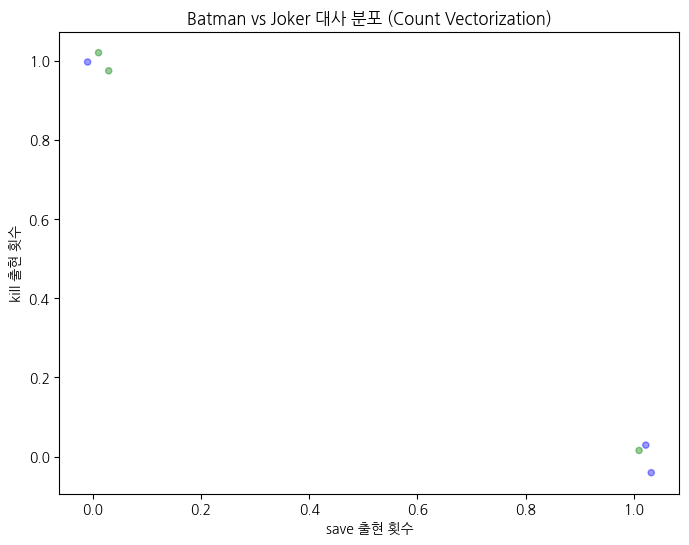

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def count_vectorize(line):
    save_count = line.lower().count("save")
    kill_count = line.lower().count("kill")
    return [save_count, kill_count]

all_lines = batman_lines + joker_lines
X = np.array([count_vectorize(line) for line in all_lines])

X_save = X[:, 0]
Y_kill = X[:, 1]

colors = ['blue'] * len(batman_lines) + ['green'] * len(joker_lines)

# jitter 추가
x_jitter = X_save + np.random.normal(0, 0.03, size=len(X_save))
y_jitter = Y_kill + np.random.normal(0, 0.03, size=len(Y_kill))

plt.figure(figsize=(8,6))
plt.scatter(x_jitter, y_jitter, c=colors, alpha=0.4, s=20)

plt.xlabel("save 출현 횟수")
plt.ylabel("kill 출현 횟수")
plt.title("Batman vs Joker 대사 분포 (Count Vectorization)")
plt.show()

In [26]:
!apt-get update -qq
!apt-get install -y fonts-nanum

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [27]:
import os
import matplotlib

cache_dir = matplotlib.get_cachedir()
print(cache_dir)
!rm -rf {cache_dir}

/root/.cache/matplotlib


In [28]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False